# Jovac mini project ( Diabetes predection from machine learning) :- Group - 4

## 1.About Dataset:
- The Diabetes Prediction dataset provides a collection of medical and demographic information from patients, including their diabetes status (positive or negative). Key features include age, gender, body mass index (BMI), hypertension, heart disease, smoking history, HbA1c levels, and blood glucose levels. 

## 2.Import our libraries 

In [57]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [58]:
import warnings
warnings.filterwarnings("ignore")

## 3.Read data from csv file

In [59]:
df = pd.read_csv('diabetes_prediction_dataset.csv')
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [60]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [61]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [62]:
df.shape

(100000, 9)

- After we makeing export to our data we see there are 100000 rows and 9 columns

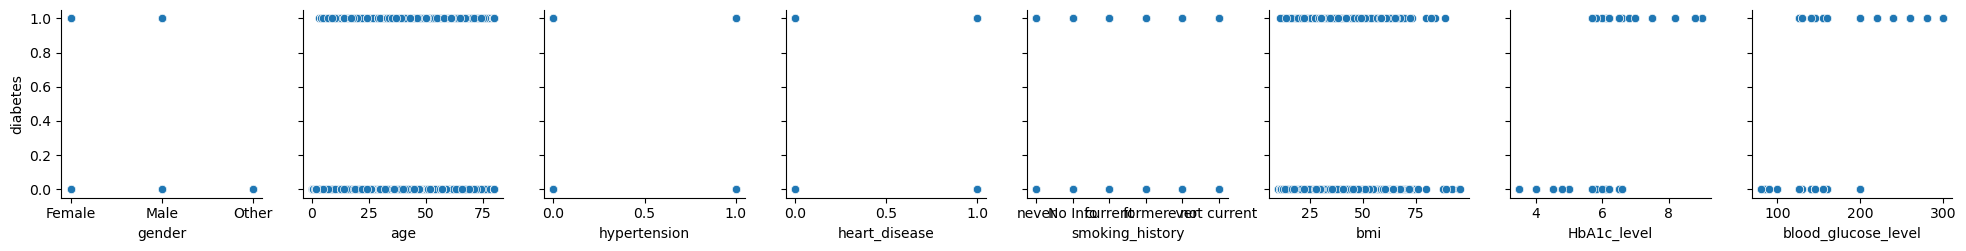

In [63]:
### checking relationship
sns.pairplot(diag_kind=None, data= df, x_vars=["gender","age","hypertension","heart_disease","smoking_history","bmi","HbA1c_level","blood_glucose_level"], y_vars="diabetes")
plt.show()

## 4.Checking information of data

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


## 5. Checking Null values

In [65]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

## 6.Duplicated Values

In [66]:
df.duplicated().sum()

3854

In [67]:
df.drop_duplicates(inplace=True)

In [68]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,No Info,24.60,4.8,145,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


## 7.Convert Columns to numeric values

In [69]:
df['gender'].value_counts()

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

In [70]:
df['smoking_history'].value_counts()

smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

In [71]:
df = pd.get_dummies(df,columns=['gender'])

In [72]:
df = pd.get_dummies(df,columns=['smoking_history'])

- After convert our columns to numeric columns we must checking our data again

In [73]:
df

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,True,False,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,True,False,False,True,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,False,True,False,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,True,False,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,36.0,0,0,24.60,4.8,145,0,True,False,False,True,False,False,False,False,False
99996,2.0,0,0,17.37,6.5,100,0,True,False,False,True,False,False,False,False,False
99997,66.0,0,0,27.83,5.7,155,0,False,True,False,False,False,False,True,False,False
99998,24.0,0,0,35.42,4.0,100,0,True,False,False,False,False,False,False,True,False


In [74]:
df.corr()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
age,1.000000,0.257305,0.238451,0.344797,0.106719,0.114317,0.264927,0.028785,-0.028580,-0.007456,-0.294166,0.033424,0.068179,0.221802,0.069213,0.069871
hypertension,0.257305,1.000000,0.119982,0.148111,0.081441,0.084834,0.195710,-0.014129,0.014240,-0.003969,-0.111535,0.015637,0.021178,0.080940,0.042553,-0.000951
heart_disease,0.238451,0.119982,1.000000,0.061376,0.068140,0.070832,0.170711,-0.078456,0.078539,-0.002822,-0.048194,0.006031,0.039469,0.093663,-0.033729,0.006810
bmi,0.344797,0.148111,0.061376,1.000000,0.084423,0.092543,0.214932,0.023484,-0.023488,0.000117,-0.229352,0.053933,0.044396,0.111806,0.088197,0.035208
HbA1c_level,0.106719,0.081441,0.068140,0.084423,1.000000,0.171615,0.406408,-0.019897,0.019944,-0.001620,-0.044146,0.005598,0.008715,0.036941,0.008967,0.009407
blood_glucose_level,0.114317,0.084834,0.070832,0.092543,0.171615,1.000000,0.424336,-0.017834,0.017824,0.000410,-0.049909,0.011962,0.005648,0.040361,0.010732,0.007870
diabetes,0.264927,0.195710,0.170711,0.214932,0.406408,0.424336,1.000000,-0.037763,0.037883,-0.004256,-0.112576,0.017037,0.021915,0.095492,0.023136,0.018921
gender_Female,0.028785,-0.014129,-0.078456,0.023484,-0.019897,-0.017834,-0.037763,1.000000,-0.999615,-0.016217,-0.055204,-0.025913,-0.010499,-0.049174,0.098894,0.012211
gender_Male,-0.028580,0.014240,0.078539,-0.023488,0.019944,0.017824,0.037883,-0.999615,1.000000,-0.011542,0.055215,0.026039,0.010473,0.049301,-0.098749,-0.012790
gender_Other,-0.007456,-0.003969,-0.002822,0.000117,-0.001620,0.000410,-0.004256,-0.016217,-0.011542,1.000000,-0.000252,-0.004450,0.000958,-0.004478,-0.005455,0.020813


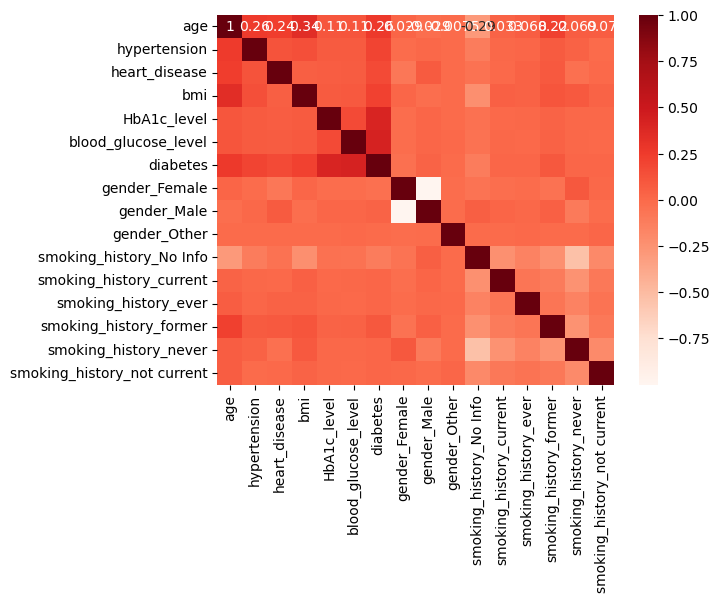

In [75]:
sns.heatmap(df.corr(), cmap="Reds", annot=True)
plt.show()

## 8.Split the columns between ' x ' and ' y '

In [76]:
X = df.drop(columns=['diabetes'])
y = df['diabetes']

## 9.Split the values between train and test values

In [77]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=.20)

## 10.Building the first model

In [78]:
model1 = DecisionTreeClassifier()
model1.fit(X_train,y_train)

DecisionTreeClassifier()

- here we are building a model from type ' Decision Tree Classifier '

In [79]:
y_pred = model1.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

- Checking the model accuracy after we are building it and makeing predict for this model

In [80]:
accuracy_score(y_test,y_pred)

0.9462298491939678

## 11.Building 2nd model

In [83]:
model2 = LogisticRegression()
model2.fit(X_train,y_train)

LogisticRegression()

In [84]:
y_pred = model2.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 1, 0], dtype=int64)

In [85]:
accuracy_score(y_test,y_pred)

0.9561622464898596

## 12.Building 3rd model

In [86]:
model3 = RandomForestClassifier(criterion='entropy',n_estimators=40) 
model3.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=40)

- This model we are give it the number of trees and this is makeing the model more slowed than ' Decision Tree Classifier '

- Predict our model

In [87]:
y_pred = model3.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

- Checking the model accuracy

In [88]:
accuracy_score(y_test,y_pred)

0.9669786791471658

## 13.Summary:
- Several machine learning models were built and tested for quality. A method was used to improve them after construction and after evaluating their quality.